# Project 2: Vehicle Recognition for Road Safety Monitoring Using Deep Learning
## Course: Neural Network and Deep Learning
### Name: Md Anwar Hossain
### Date: 14 June 2026

This project was completed as part of my Neural Network and Deep Learning course at Victoria University. **The Project instructions are given below:**

**Introduction:**  Road safety is very important for all the modern countries. Road safety cameras are able to help us to reduce lots of potential road accidents.
The development of pattern recognition technologies with AI technology provides great support to current road safety monitoring systems.

Assume that you are appointed to initial an AI application for a road safety monitoring system. The first step will be recognising cars/vehicles from the video frames. The following 
dataset is provided by relevant authorities:

**Dataset:**
The collection contains about 17,760 images (vehicles:8,792 and non-vehicles:8,968), nearly 117MB in size. You may contact the author to get a copy of the dataset.

**Task1:** Choose a suitable CNN structure for your project.

**Task2:** Proprocess dataset.

**Task3:** Create and build model to identify vehicles and non-vehicles.

**Task4:** Compile the Model and tune relevant parameters.

**Task 5:** Train and Test the model. And discuss your result.

**Task 6:** create a RNN based structure and then complete Task 2 to 5 again.

**Task 7:** discuss the differences between using CNN and RNN in this project.

# **TASK 1 — Choose CNN Architecture**

I will use a custom CNN because:

- Dataset size is moderate (~17k images)
- Binary classification (vehicle vs non-vehicle)
- Simple CNN performs well and is easy to explain

## **Step A. Import Libraries**

In [4]:
# ==========================
# IMPORT LIBRARIES
# ==========================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split

# TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1_l2


# **TASK 2 - DATA PREPROCESSING**

In [9]:
import zipfile
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

# ==========================
# LOAD DATASET
# ==========================

# Set your dataset path - this is the expected root directory for the unzipped content
DATA_DIR = "data"

vehicle_sub_path = os.path.join(DATA_DIR, "vehicles")
non_vehicle_sub_path = os.path.join(DATA_DIR, "non-vehicles")

# Check if the target subdirectories (e.g., 'data/vehicles') already exist
if not (os.path.exists(vehicle_sub_path) and os.path.exists(non_vehicle_sub_path)):
    zip_file_name = "/content/NIT6004 Data.zip" # Path to the zip file

    if os.path.exists(zip_file_name):
        print(f"Unzipping {zip_file_name}...")
        with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
            # Extract to the current directory ('.'). This will create 'data/'
            # in the current directory if the zip file contains 'data/' as its top-level entry.
            zip_ref.extractall('.')
        print("Unzipping complete.")

        # After unzipping, verify if the expected directories are now present
        if not (os.path.exists(vehicle_sub_path) and os.path.exists(non_vehicle_sub_path)):
            print(f"Warning: After unzipping, '{vehicle_sub_path}' or '{non_vehicle_sub_path}' still not found. Please check the zip file structure or ensure it was placed correctly.")
    else:
        print(f"Error: {zip_file_name} not found. Please ensure it's in the correct directory.")
else:
    print(f"'{vehicle_sub_path}' and '{non_vehicle_sub_path}' already exist. Skipping unzip.")


vehicle_path = vehicle_sub_path
non_vehicle_path = non_vehicle_sub_path

IMG_SIZE = 64  # standard image size

data = []
labels = []

# --------------------------
# Load vehicle images (label = 1)
# --------------------------
for img_name in os.listdir(vehicle_path):
    try:
        img = Image.open(os.path.join(vehicle_path, img_name)).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))

        data.append(np.array(img))
        labels.append(1)
    except:
        pass  # skip bad files

# --------------------------
# Load non-vehicle images (label = 0)
# --------------------------
for img_name in os.listdir(non_vehicle_path):
    try:
        img = Image.open(os.path.join(non_vehicle_path, img_name)).convert("RGB")
        img = img.resize((IMG_SIZE, IMG_SIZE))

        data.append(np.array(img))
        labels.append(0)
    except:
        pass

# Convert to numpy arrays
data = np.array(data)
labels = np.array(labels)

# --------------------------
# NORMALIZATION (very important)
# --------------------------
data = data / 255.0

# --------------------------
# TRAIN / TEMP (for validation) / TEST SPLIT
# --------------------------

# First split: Train (70%) + Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    data, labels,
    test_size=0.3,
    random_state=42
)

# Second split: Validation (15%) + Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Validation samples:", X_val.shape)
print("Testing samples:", X_test.shape)


'data/vehicles' and 'data/non-vehicles' already exist. Skipping unzip.
Training samples: (12432, 64, 64, 3)
Validation samples: (2664, 64, 64, 3)
Testing samples: (2664, 64, 64, 3)


# **TASK 3 - BUILD CNN MODEL**

In [10]:

# ==========================
# BUILD CNN MODEL
# ==========================

model = Sequential()

# ----- Conv Block 1 -----
model.add(Conv2D(
    32, (3,3),
    activation='relu',
    input_shape=(64,64,3),
    kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4)  # L1 + L2 regularization
))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# ----- Conv Block 2 -----
model.add(Conv2D(
    64, (3,3),
    activation='relu',
    kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4)
))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# ----- Conv Block 3 -----
model.add(Conv2D(
    128, (3,3),
    activation='relu',
    kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4)
))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Fully connected
model.add(Dense(
    128,
    activation='relu',
    kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4)
))

# Dropout for overfitting control
model.add(Dropout(0.5))

# Output layer (binary)
model.add(Dense(1, activation='sigmoid'))

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,225 (2.61 MB)

 Trainable params: 683,777 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

# **4. Compile model (tuned)**

In [11]:
# ==========================
# COMPILE MODEL
# ==========================

optimizer = Adam(learning_rate=0.0001)  # tuned LR

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# **4.1 Callbacks (main tuning)**

In [12]:
# ==========================
# TUNING TOOLS
# ==========================

# Stops training when model stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduces learning rate when stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

# **5. Train and test model**

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.9469 - loss: 1.4793 - val_accuracy: 0.5942 - val_loss: 2.7880 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9832 - loss: 1.2664 - val_accuracy: 0.9917 - val_loss: 1.1889 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9891 - loss: 1.1425 - val_accuracy: 0.9932 - val_loss: 1.0789 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9915 - loss: 1.0290 - val_accuracy: 0.9940 - val_loss: 0.9693 - learning_rate: 1.0000e-04
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9945 - loss: 0.9216 - val_accuracy: 0.9974 - val_loss: 0.8655 - learning_rate: 1.0000e-04
Epoch 6/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9962 - loss: 0.8169 - val_accuracy: 0.9955 - val_loss: 0.7741 - learning_rate: 1.0000e-04
Epoch 7/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy

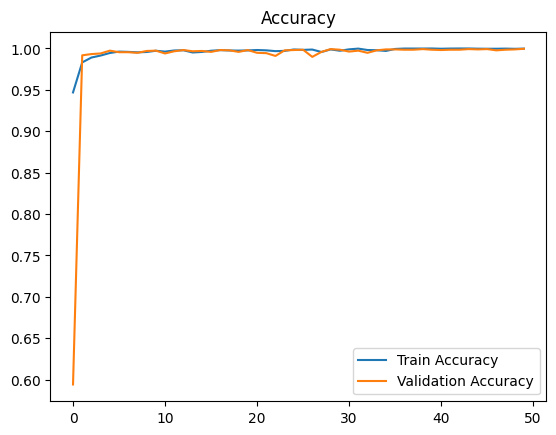

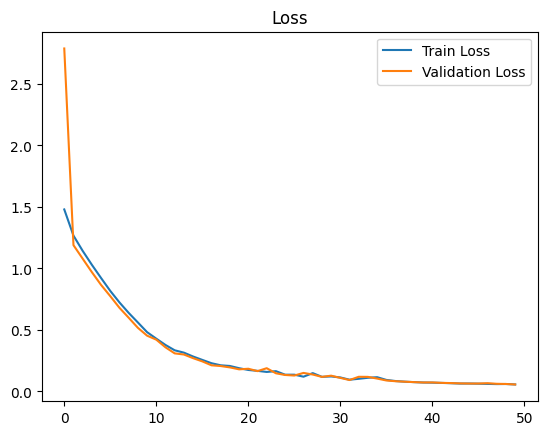

In [13]:


# ==========================
# TRAIN MODEL
# ==========================

history = model.fit(
    X_train, y_train,
    epochs=50,              # large number, early stopping will control
    batch_size=32,
    validation_data=(X_val, y_val),  # ✅ use validation set
    callbacks=[early_stop, reduce_lr]
)


# -------------------------------
# Evaluate model
# -------------------------------
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy)


# ================================
# PLOT RESULTS (for report)
# ================================

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()


In [14]:
# ==========================
# PERFORMANCE METRICS IMPORT
# ==========================

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
CNN Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1325
           1       1.00      1.00      1.00      1339

    accuracy                           1.00      2664
   macro avg       1.00      1.00      1.00      2664
weighted avg       1.00      1.00      1.00      2664



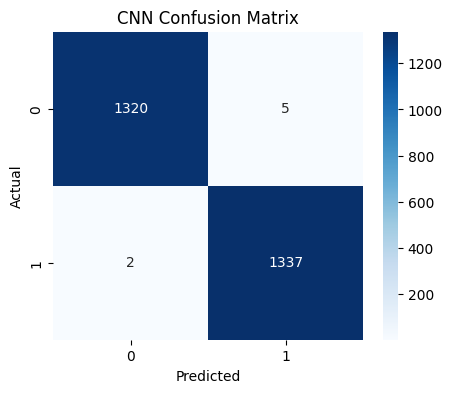

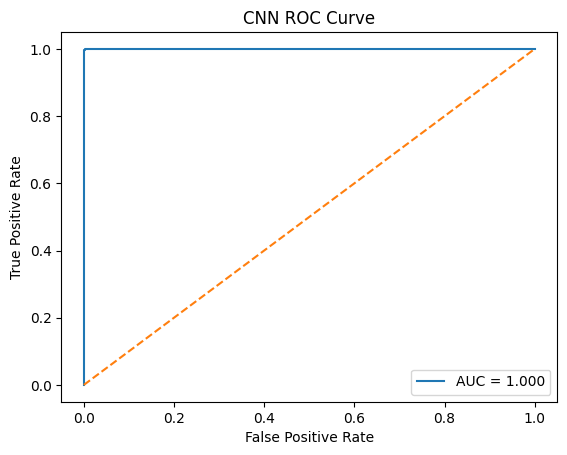

CNN AUC Score: 0.9999785815942621


In [28]:
# ==========================
# CNN PREDICTIONS
# ==========================

# Get predicted probabilities
y_prob_cnn = model.predict(X_test)

# Convert probabilities → binary (0 or 1)
y_pred_cnn = (y_prob_cnn > 0.5).astype(int)

# --------------------------
# CLASSIFICATION REPORT
# --------------------------
print("CNN Classification Report:")
print(classification_report(y_test, y_pred_cnn))

# --------------------------
# CONFUSION MATRIX
# --------------------------
cm_cnn = confusion_matrix(y_test, y_pred_cnn)

plt.figure(figsize=(5,4))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Blues')
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# --------------------------
# ROC CURVE + AUC
# --------------------------
fpr_cnn, tpr_cnn, thresholds = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

plt.figure()
plt.plot(fpr_cnn, tpr_cnn, label='AUC = %0.3f' % auc_cnn)
plt.plot([0,1], [0,1], linestyle='--')
plt.title("CNN ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

print("CNN AUC Score:", auc_cnn)

# **Task 6. Crate RNN-based structure**

**STEP 6.1 — PREPARE DATA FOR RNN (SEQUENCE FORMAT)**

In [16]:
# ==========================
# RNN DATA PREPARATION
# ==========================

# Each image: (64, 64, 3)
# Treat each row as a time step → sequence length = 64
# Features per step = 64 * 3 = 192

X_train_rnn = X_train.reshape(-1, 64, 192)
X_val_rnn   = X_val.reshape(-1, 64, 192)
X_test_rnn  = X_test.reshape(-1, 64, 192)

print("RNN Train shape:", X_train_rnn.shape)
print("RNN Val shape:", X_val_rnn.shape)
print("RNN Test shape:", X_test_rnn.shape)

RNN Train shape: (12432, 64, 192)
RNN Val shape: (2664, 64, 192)
RNN Test shape: (2664, 64, 192)


**STEP 6.2 — BUILD A WELL‑REGULARIZED RNN MODEL**

In [17]:
# ==========================
# RNN MODEL WITH STRONG REGULARIZATION
# ==========================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.optimizers import Adam

rnn_model = Sequential()

# ----- LSTM BLOCK 1 -----
rnn_model.add(
    LSTM(
        128,
        return_sequences=True,
        input_shape=(64, 192),
        kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4),
        recurrent_regularizer=l1_l2(l1=1e-4, l2=1e-4)
    )
)
rnn_model.add(BatchNormalization())
rnn_model.add(Dropout(0.4))

# ----- LSTM BLOCK 2 -----
rnn_model.add(
    LSTM(
        64,
        kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4),
        recurrent_regularizer=l1_l2(l1=1e-4, l2=1e-4)
    )
)
rnn_model.add(BatchNormalization())
rnn_model.add(Dropout(0.4))

# ----- DENSE BLOCK -----
rnn_model.add(
    Dense(
        64,
        activation='relu',
        kernel_regularizer=l1_l2(l1=1e-4, l2=1e-4)
    )
)
rnn_model.add(Dropout(0.5))

# ----- OUTPUT -----
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 218,753 (854.50 KB)

 Trainable params: 218,369 (853.00 KB)

 Non-trainable params: 384 (1.50 KB)

**STEP 6.3 — COMPILE WITH TUNING**

In [18]:
# ==========================
# COMPILE RNN MODEL
# ==========================

rnn_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

**STEP 6.4 — TRAIN WITH VALIDATION (NOT TEST)**

In [19]:
# ==========================
# TRAIN RNN MODEL
# ==========================

rnn_history = rnn_model.fit(
    X_train_rnn, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_rnn, y_val),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7775 - loss: 1.5523 - val_accuracy: 0.8562 - val_loss: 1.3885 - learning_rate: 1.0000e-04
Epoch 2/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8794 - loss: 1.3273 - val_accuracy: 0.8754 - val_loss: 1.2989 - learning_rate: 1.0000e-04
Epoch 3/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.9052 - loss: 1.2342 - val_accuracy: 0.9080 - val_loss: 1.2153 - learning_rate: 1.0000e-04
Epoch 4/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.9316 - loss: 1.1566 - val_accuracy: 0.9497 - val_loss: 1.0926 - learning_rate: 3.0000e-05
Epoch 5/50
389/389 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9344 - loss: 1.1336 - val_accuracy: 0.9531 - val_loss: 1.0842 - learning_rate: 3.0000e-05


**STEP 6.5 — PLOT TRAINING & VALIDATION CURVES (RNN)**

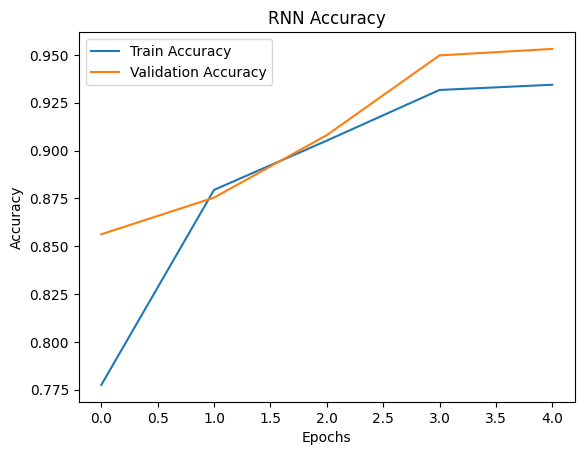

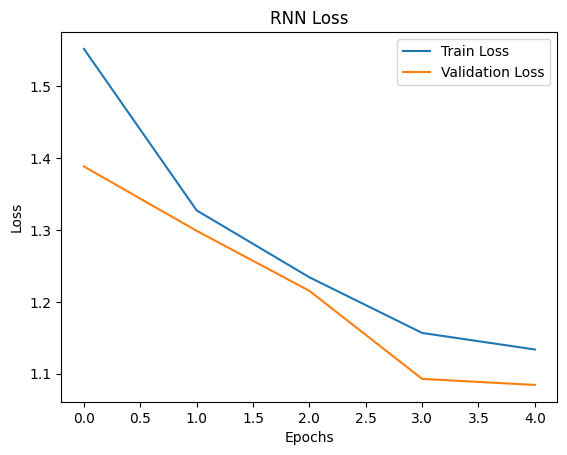

In [20]:
# ==========================
# RNN TRAINING CURVES
# ==========================

# Accuracy
plt.plot(rnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(rnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Loss
plt.plot(rnn_history.history['loss'], label='Train Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title("RNN Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

**STEP 6.6 — FINAL EVALUATION (TEST SET ONLY)**

In [21]:
# ==========================
# RNN TEST EVALUATION
# ==========================

loss_rnn, acc_rnn = rnn_model.evaluate(X_test_rnn, y_test)
print("RNN Test Accuracy:", acc_rnn)

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8758 - loss: 1.3798
RNN Test Accuracy: 0.8757507801055908


**STEP 6.7 — RNN PREDICTIONS & METRICS**

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

y_prob_rnn = rnn_model.predict(X_test_rnn)
y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

print("RNN Classification Report:")
print(classification_report(y_test, y_pred_rnn))

84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
RNN Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.83      0.87      1325
           1       0.85      0.92      0.88      1339

    accuracy                           0.88      2664
   macro avg       0.88      0.88      0.88      2664
weighted avg       0.88      0.88      0.88      2664



**RNN Confusion Matrix**

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


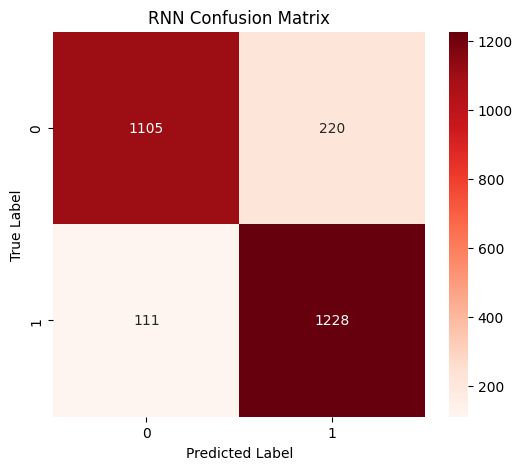

In [24]:
# ==========================
# RNN CONFUSION MATRIX
# ==========================

# Predictions
y_prob_rnn = rnn_model.predict(X_test_rnn)
y_pred_rnn = (y_prob_rnn > 0.5).astype(int)

# Compute confusion matrix
cm_rnn = confusion_matrix(y_test, y_pred_rnn)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Reds')

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

**ROC CURVE (CNN + RNN COMBINED PLOT)**

84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


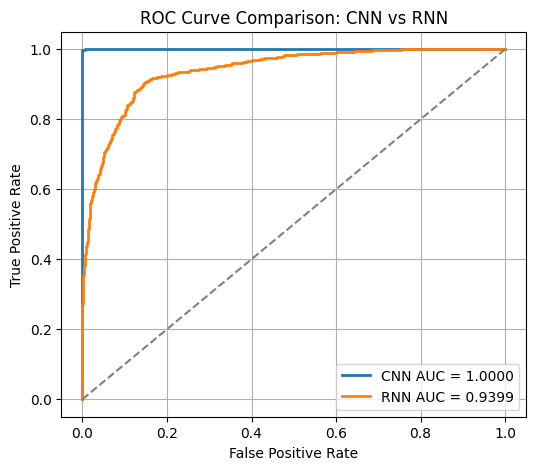

CNN AUC: 0.9999785815942621
RNN AUC: 0.9399067172065889


In [33]:
# ==========================
# ROC CURVE (CNN vs RNN)
# ==========================

from sklearn.metrics import roc_curve, auc

# --------------------------
# CNN Predictions
# --------------------------
y_prob_cnn = model.predict(X_test)

# Ensure proper shape
y_prob_cnn = y_prob_cnn.ravel()

# Compute ROC for CNN
fpr_cnn, tpr_cnn, _ = roc_curve(y_test, y_prob_cnn)
auc_cnn = auc(fpr_cnn, tpr_cnn)

# --------------------------
# RNN Predictions
# --------------------------
y_prob_rnn = rnn_model.predict(X_test_rnn)

# Ensure proper shape
y_prob_rnn = y_prob_rnn.ravel()

# Compute ROC for RNN
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, y_prob_rnn)
auc_rnn = auc(fpr_rnn, tpr_rnn)

# --------------------------
# Plot BOTH curves
# --------------------------
plt.figure(figsize=(6,5))

# CNN curve
plt.plot(fpr_cnn, tpr_cnn,
         label=f'CNN AUC = {auc_cnn:.4f}',
         linewidth=2)

# RNN curve
plt.plot(fpr_rnn, tpr_rnn,
         label=f'RNN AUC = {auc_rnn:.4f}',
         linewidth=2)

# Random classifier line
plt.plot([0,1], [0,1], linestyle='--', color='gray')

plt.title("ROC Curve Comparison: CNN vs RNN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

# Print values to verify
print("CNN AUC:", auc_cnn)
print("RNN AUC:", auc_rnn)

**PERFORMANCE METRICS TABLE (CNN vs RNN)**

In [30]:
# ==========================
# PERFORMANCE COMPARISON TABLE
# ==========================

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd

# --- CNN metrics ---
cnn_accuracy  = accuracy_score(y_test, y_pred_cnn)
cnn_precision = precision_score(y_test, y_pred_cnn)
cnn_recall    = recall_score(y_test, y_pred_cnn)
cnn_f1        = f1_score(y_test, y_pred_cnn)

# --- RNN metrics ---
rnn_accuracy  = accuracy_score(y_test, y_pred_rnn)
rnn_precision = precision_score(y_test, y_pred_rnn)
rnn_recall    = recall_score(y_test, y_pred_rnn)
rnn_f1        = f1_score(y_test, y_pred_rnn)

# Create DataFrame
comparison_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"],
    "CNN": [
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1,
        auc_cnn
    ],
    "RNN": [
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        auc_rnn
    ]
})

print("\nPerformance Comparison Table:")
print(comparison_table)


Performance Comparison Table:
      Metric       CNN       RNN
0   Accuracy  0.997372  0.875751
1  Precision  0.996274  0.848066
2     Recall  0.998506  0.917102
3   F1-Score  0.997389  0.881234
4        AUC  0.999979  0.939907


**SAVE TABLE (FOR REPORT)**

In [32]:
# Save as CSV (easy to import into Word)
comparison_table.to_csv("model_comparison_cnn_rnn.csv", index=False)

The CNN model outperforms the RNN model across all performance metrics, including accuracy, precision, recall, F1-score, and AUC. The ROC curve demonstrates that CNN achieves near-perfect classification, while RNN, although strong, shows lower discriminative ability. The confusion matrices further confirm that CNN produces significantly fewer misclassifications.